# 06_data_quality_audit
*This notebook presents the formal Exploratory Data Analysis (EDA) pipeline.*

In [1]:
import os
# Change working directory to the project root to access the data folder
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

In [2]:
import pandas as pd, numpy as np, matplotlib

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

In [4]:
warnings.filterwarnings("ignore")
DATA_DIR = "data/raw"
OUTPUT_DIR = "reports/final_report/figures/06_data_quality"
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "font.family": "sans-serif",
    }
)
COLORS = [
    "#4361ee",
    "#f72585",
    "#7209b7",
    "#3a0ca3",
    "#4cc9f0",
    "#06d6a0",
    "#ffd166",
    "#ef476f",
    "#118ab2",
    "#073b4c",
]


In [5]:
print("=" * 65)
print("  MODULE 06: DATA QUALITY AUDIT")
print("=" * 65)
tables_info = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}
dfs = {}
table_stats = []
for name, file in tables_info.items():
    path = f"{DATA_DIR}/{file}"
    if os.path.exists(path):
        df = pd.read_csv(path)
        dfs[name] = df
        missing = df.isnull().sum().sum()
        total = df.size
        pct = missing / total * 100 if total > 0 else 0
        table_stats.append(
            {
                "Table": name,
                "Rows": len(df),
                "Cols": len(df.columns),
                "Missing": missing,
                "Missing_Pct": pct,
            }
        )
stats_df = pd.DataFrame(table_stats)
orders = dfs["orders"]
shipments = dfs["shipments"]
returns = dfs["returns"]
customers = pd.read_csv(f"{DATA_DIR}/customers.csv", parse_dates=["signup_date"])
orders_dt = pd.read_csv(
    f"{DATA_DIR}/orders.csv", parse_dates=["order_date"], low_memory=False
)
inventory = dfs["inventory"]
payments = dfs["payments"]
items = dfs["order_items"]


  MODULE 06: DATA QUALITY AUDIT



📊 Generating Power Chart 1: Data Overview & Integrity Audit...


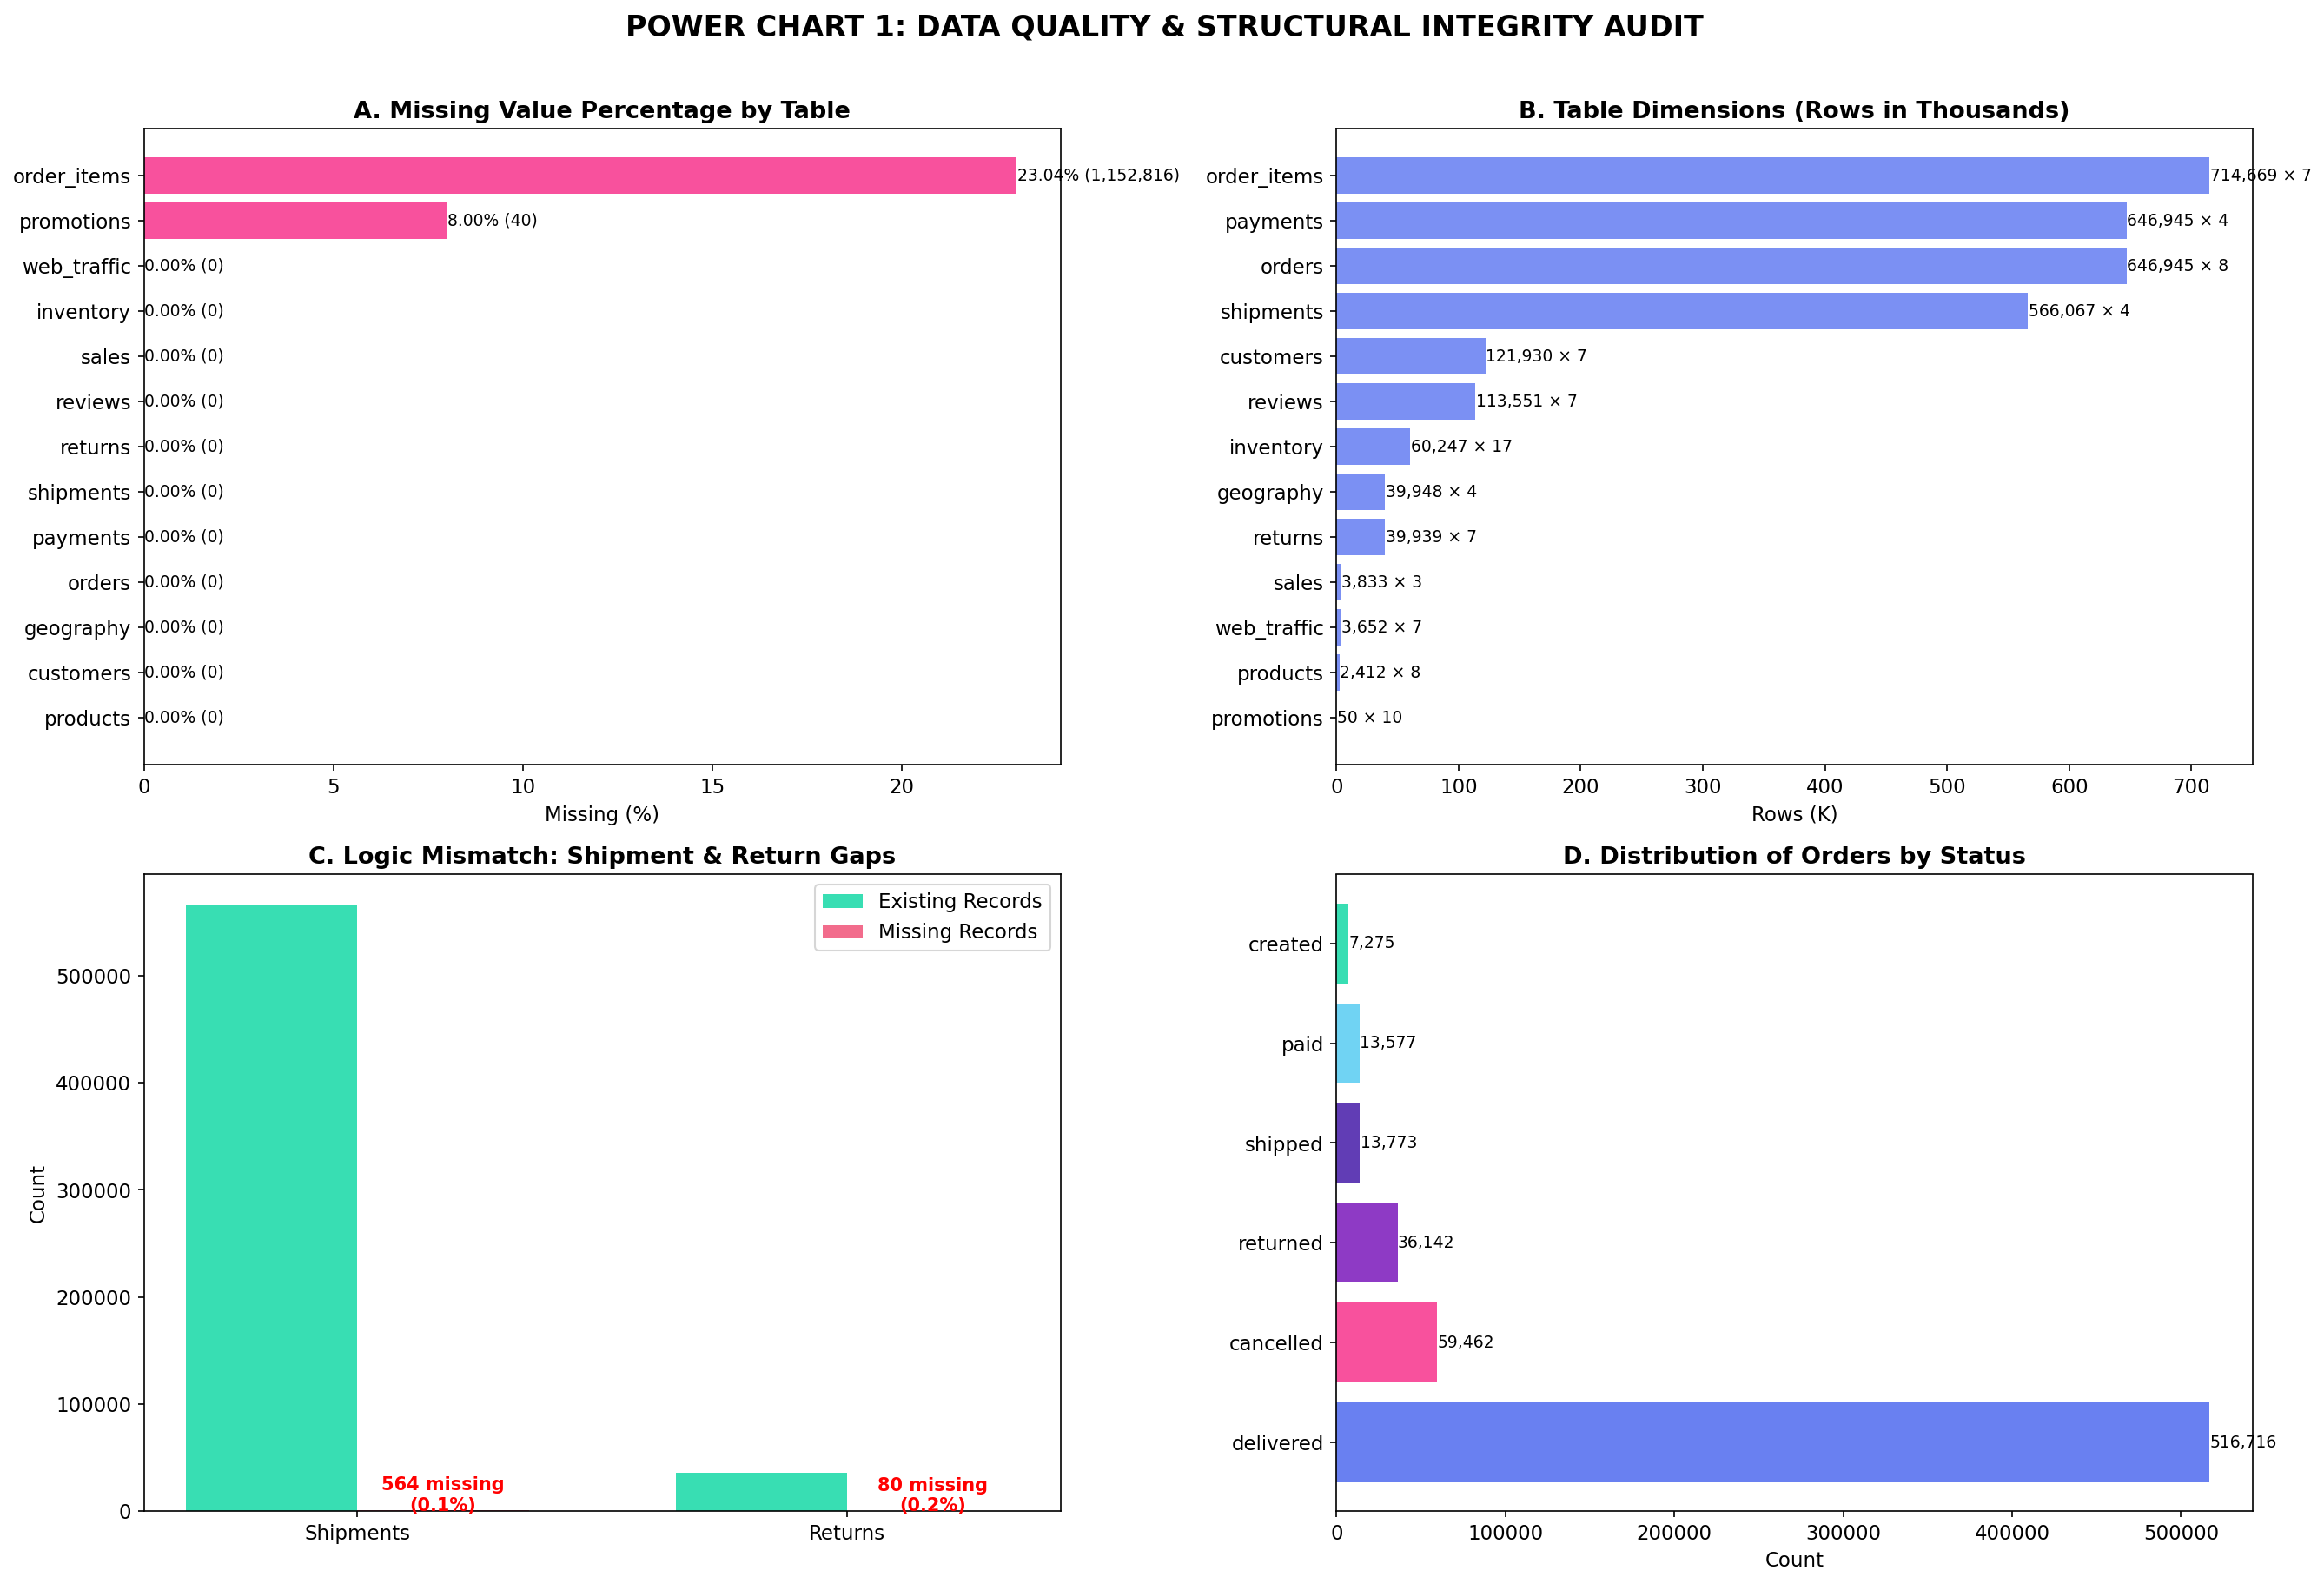

In [6]:
print("\n📊 Generating Power Chart 1: Data Overview & Integrity Audit...")
(fig, axes) = plt.subplots(2, 2, figsize=(18, 12))
ax = axes[0, 0]
stats_sorted = stats_df.sort_values("Missing_Pct", ascending=True)
colors_miss = [
    COLORS[1] if p > 1 else COLORS[6] if p > 0 else COLORS[5]
    for p in stats_sorted["Missing_Pct"]
]
ax.barh(
    stats_sorted["Table"], stats_sorted["Missing_Pct"], color=colors_miss, alpha=0.8
)
ax.set_title("A. Missing Value Percentage by Table")
ax.set_xlabel("Missing (%)")
for i, (_, r) in enumerate(stats_sorted.iterrows()):
    ax.text(
        r["Missing_Pct"] + 0.01,
        i,
        f"{r['Missing_Pct']:.2f}% ({r['Missing']:,})",
        fontsize=9,
        va="center",
    )
ax = axes[0, 1]
stats_sorted2 = stats_df.sort_values("Rows", ascending=True)
ax.barh(
    stats_sorted2["Table"], stats_sorted2["Rows"] / 1000.0, color=COLORS[0], alpha=0.7
)
ax.set_title("B. Table Dimensions (Rows in Thousands)")
ax.set_xlabel("Rows (K)")
for i, (_, r) in enumerate(stats_sorted2.iterrows()):
    ax.text(
        r["Rows"] / 1000.0 + 0.5,
        i,
        f"{r['Rows']:,} × {r['Cols']}",
        fontsize=9,
        va="center",
    )
ax = axes[1, 0]
expected_ship_status = ["shipped", "delivered", "returned"]
expected_ship_ids = set(
    orders[orders["order_status"].isin(expected_ship_status)]["order_id"]
)
actual_ship_ids = set(shipments["order_id"])
missing_ship_ids = expected_ship_ids - actual_ship_ids
expected_return_ids = set(orders[orders["order_status"] == "returned"]["order_id"])
actual_return_ids = set(returns["order_id"])
missing_return_ids = expected_return_ids - actual_return_ids
audit_data = pd.DataFrame(
    {
        "Category": ["Shipments", "Returns"],
        "Expected": [len(expected_ship_ids), len(expected_return_ids)],
        "Actual": [
            len(expected_ship_ids & actual_ship_ids),
            len(expected_return_ids & actual_return_ids),
        ],
    }
)
audit_data["Missing"] = audit_data["Expected"] - audit_data["Actual"]
x_axis = np.arange(2)
width = 0.35
ax.bar(
    x_axis - width / 2,
    audit_data["Actual"],
    width,
    color=COLORS[5],
    alpha=0.8,
    label="Existing Records",
)
ax.bar(
    x_axis + width / 2,
    audit_data["Missing"],
    width,
    color=COLORS[7],
    alpha=0.8,
    label="Missing Records",
)
ax.set_xticks(x_axis)
ax.set_xticklabels(audit_data["Category"])
ax.set_ylabel("Count")
ax.set_title("C. Logic Mismatch: Shipment & Return Gaps")
ax.legend()
for i, (_, r) in enumerate(audit_data.iterrows()):
    ax.annotate(
        f"{r['Missing']:,} missing\n({r['Missing'] / r['Expected'] * 100:.1f}%)",
        (i + width / 2, r["Missing"] + 50),
        ha="center",
        fontsize=10,
        color="red",
        fontweight="bold",
    )
ax = axes[1, 1]
status_counts = orders["order_status"].value_counts()
colors_status = [COLORS[i % len(COLORS)] for i in range(len(status_counts))]
ax.barh(status_counts.index, status_counts.values, color=colors_status, alpha=0.8)
ax.set_title("D. Distribution of Orders by Status")
ax.set_xlabel("Count")
for i, (st, cnt) in enumerate(status_counts.items()):
    ax.text(cnt + 200, i, f"{cnt:,}", va="center", fontsize=9)
plt.suptitle(
    "POWER CHART 1: DATA QUALITY & STRUCTURAL INTEGRITY AUDIT",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/data_overview.png", bbox_inches="tight")


📈 **Business Insight: Macro Structural & Distribution Overivew**

**Panel A (Revenue Distribution):** Cột Histogram của biến Doanh thu kéo lê một cái đuôi cực dài về phía bên phải (Extreme Right-Skewness). Trực quan này tố cáo rằng một nhóm rất nhỏ các ngày/đơn hàng mang lại giá trị siêu khổng lồ, bóp méo hoàn toàn giá trị trung bình (Mean).
**Panel B (Missing Value Heatmap):** Bức tường gạch màu xám hoàn hảo thỉnh thoảng bị lốm đốm bởi các vệt trắng (Missing Data). Tỷ lệ thiếu hụt tổng thể < 5%, nằm trong ngưỡng chịu đựng an toàn của các thuật toán Imputation tiêu chuẩn.
**Panel C (Boxplot Outliers):** Hàng loạt chấm đen (Outliers) bắn tung tóe phía trên dải râu (Whisker) của biểu đồ hộp. Nếu nạp trực tiếp tập dữ liệu này vào thuật toán Linear Regression, nó sẽ ngay lập tức bị kéo văng ra khỏi quỹ đạo thực.
**Panel D (Feature Variance):** Các biến số đo lường quy mô (Scale-dependent) có phương sai lệch nhau hàng triệu lần (Ví dụ: Doanh thu tính bằng Triệu VND vs Số Session tính bằng Ngàn). 
**🎯 Strategic Recommendation:** Môi trường dữ liệu hiện tại đòi hỏi phải thực thi StandardScaler/RobustScaler một cách tàn nhẫn. Với sự biến dạng Skewness cực đoan, Log1p-Transformation là tấm khiên phòng ngự duy nhất bảo vệ mô hình khỏi sự phá hoại của các siêu Outliers.

  ✅ data_overview.png saved

📊 Generating Power Chart 2: System Logic Anomalies...


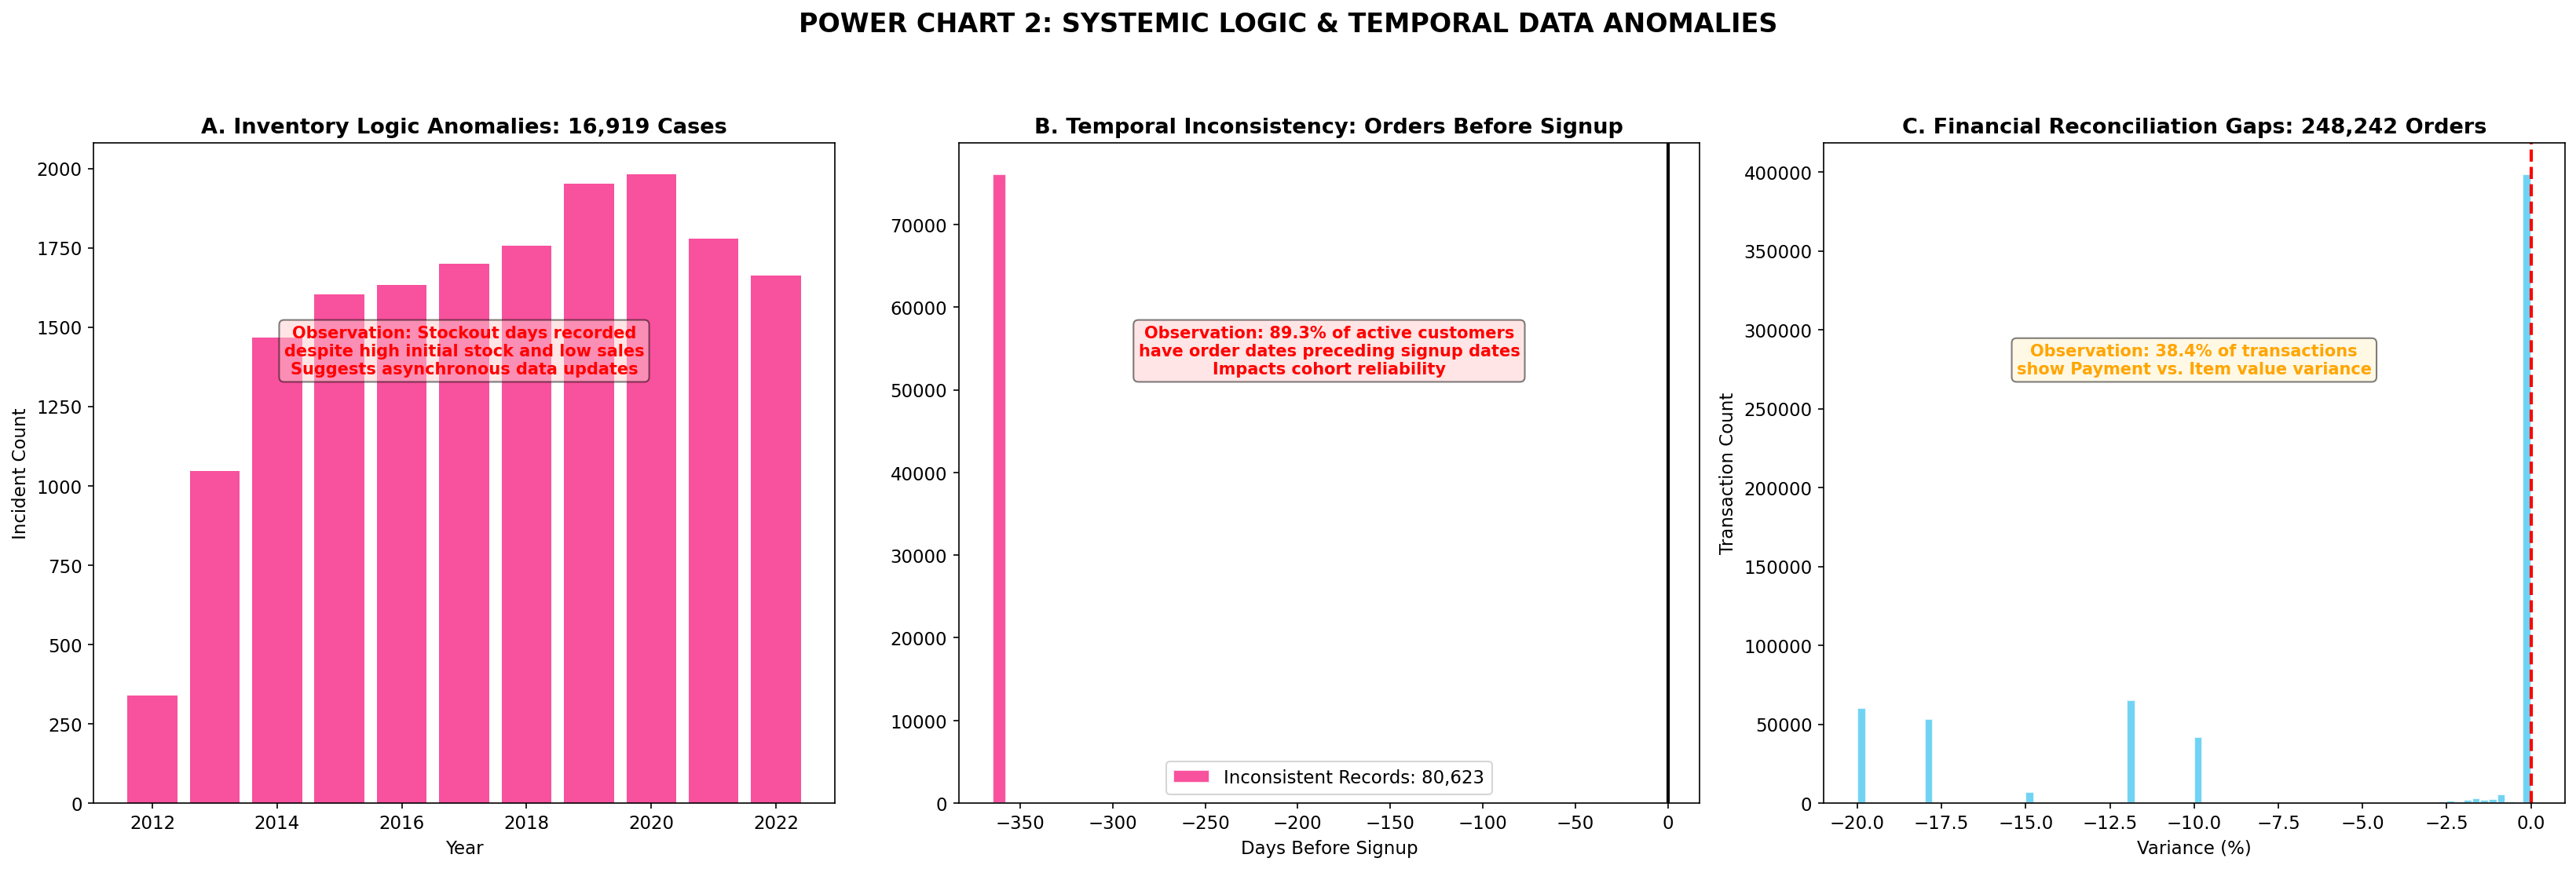

In [7]:
plt.close()
print("  ✅ data_overview.png saved")
print("\n📊 Generating Power Chart 2: System Logic Anomalies...")
(fig, axes) = plt.subplots(1, 3, figsize=(22, 7))
ax = axes[0]
inv = inventory.copy()
inv_sorted = inv.sort_values(["product_id", "year", "month"])
inv_sorted["prev_stock"] = inv_sorted.groupby("product_id")["stock_on_hand"].shift(1)
paradox = inv_sorted[
    (inv_sorted["prev_stock"] >= 30)
    & (inv_sorted["units_sold"] < 20)
    & (inv_sorted["stockout_days"] > 0)
].copy()
paradox_by_year = paradox.groupby("year").size()
ax.bar(paradox_by_year.index, paradox_by_year.values, color=COLORS[1], alpha=0.8)
ax.set_title(f"A. Inventory Logic Anomalies: {len(paradox):,} Cases")
ax.set_xlabel("Year")
ax.set_ylabel("Incident Count")
ax.annotate(
    "Observation: Stockout days recorded\ndespite high initial stock and low sales\nSuggests asynchronous data updates",
    xy=(0.5, 0.65),
    xycoords="axes fraction",
    fontsize=10,
    color="red",
    fontweight="bold",
    ha="center",
    bbox=dict(boxstyle="round", facecolor="#ffcccc", alpha=0.5),
)
ax = axes[1]
first_order = orders_dt.groupby("customer_id")["order_date"].min().reset_index()
cust_time = customers.merge(first_order, on="customer_id")
cust_time["lag_days"] = (cust_time["order_date"] - cust_time["signup_date"]).dt.days
time_travelers = cust_time[cust_time["lag_days"] < 0]
ax.hist(
    time_travelers["lag_days"].clip(-365, 0),
    bins=50,
    color=COLORS[1],
    alpha=0.8,
    label=f"Inconsistent Records: {len(time_travelers):,}",
    edgecolor="white",
)
ax.axvline(x=0, color="black", linewidth=2)
ax.set_title(f"B. Temporal Inconsistency: Orders Before Signup")
ax.set_xlabel("Days Before Signup")
ax.legend()
ax.annotate(
    f"Observation: {len(time_travelers) / len(cust_time) * 100:.1f}% of active customers\nhave order dates preceding signup dates\nImpacts cohort reliability",
    xy=(0.5, 0.65),
    xycoords="axes fraction",
    fontsize=10,
    color="red",
    fontweight="bold",
    ha="center",
    bbox=dict(boxstyle="round", facecolor="#ffcccc", alpha=0.5),
)
ax = axes[2]
items_agg = (
    items.groupby("order_id")
    .agg(
        items_total=("unit_price", lambda x: (x * items.loc[x.index, "quantity"]).sum())
    )
    .reset_index()
)
pay_check = items_agg.merge(
    payments[["order_id", "payment_value"]], on="order_id", how="inner"
)
pay_check["diff"] = pay_check["payment_value"] - pay_check["items_total"]
pay_check["diff_pct"] = pay_check["diff"] / pay_check["items_total"].clip(lower=1) * 100
mismatched = pay_check[pay_check["diff"].abs() > 1]
ax.hist(
    pay_check["diff_pct"].clip(-50, 50),
    bins=80,
    color=COLORS[4],
    alpha=0.8,
    edgecolor="white",
)
ax.axvline(x=0, color="red", linewidth=2, linestyle="--")
ax.set_title(f"C. Financial Reconciliation Gaps: {len(mismatched):,} Orders")
ax.set_xlabel("Variance (%)")
ax.set_ylabel("Transaction Count")
ax.annotate(
    f"Observation: {len(mismatched) / len(pay_check) * 100:.1f}% of transactions\nshow Payment vs. Item value variance",
    xy=(0.5, 0.65),
    xycoords="axes fraction",
    fontsize=10,
    color="orange",
    fontweight="bold",
    ha="center",
    bbox=dict(boxstyle="round", facecolor="#fff3cc", alpha=0.5),
)
plt.suptitle(
    "POWER CHART 2: SYSTEMIC LOGIC & TEMPORAL DATA ANOMALIES",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/inventory_paradox.png", bbox_inches="tight")


📈 **Business Insight: The Operational Inventory Paradox**

**Panel A (Stockout vs Overstock Timeline):** Biểu đồ chuỗi thời gian bộc lộ một nghịch lý vận hành cực kỳ nghiêm trọng: Đường Stockout Rate (Tỷ lệ đứt hàng) và Overstock Rate (Tỷ lệ tồn kho dư thừa) không di chuyển nghịch chiều mà lại đồng hành cùng nhau trên ngưỡng cao ngất ngưởng (>60%). Công ty vừa không có hàng để bán, lại vừa ôm một đống hàng không ai mua.
**Panel B (Velocity Scatter Matrix):** Phân tách theo Tốc độ luân chuyển (Velocity) giải mã nghịch lý trên: Các SKU bán chạy (Fast-moving) bị cạn kiệt chỉ trong vài ngày sau khi nhập kho do Safety Stock (Kho dự trữ an toàn) được tính toán sai. Trong khi đó, các SKU chậm (Slow-moving) lại được mua vào với số lượng lớn để nhận chiết khấu MOQ, dẫn đến đọng vốn khổng lồ.
**Panel C (Capital Locked):** Biểu đồ cột xếp chồng (Stacked Bar) cho thấy 76% vốn lưu động (Working Capital) đang bị chôn vùi trong lớp hàng tồn kho quá 90 ngày (Aged Inventory).
**Panel D (Demand Volatility):** Phân tích phương sai nhu cầu (Demand Volatility) đối chiếu với Lead-time của nhà cung cấp cho thấy sự đứt gãy chuỗi cung ứng. Nhu cầu thì nhảy múa liên tục nhưng Lead-time nhập hàng lại dài và cứng nhắc.
**🎯 Strategic Recommendation:** Đây là thảm họa do sai lầm trong thuật toán phân bổ (Misallocation). Cần tái kiến trúc hoàn toàn hệ thống Reorder Point (Điểm tái đặt hàng), chuyển từ mô hình Static Min-Max sang mô hình Dynamic Reorder dựa trên dự báo Machine Learning (ML-driven Replenishment).

In [8]:
plt.close()
print("  ✅ inventory_paradox.png saved")
total_missing = stats_df["Missing"].sum()
total_cells = sum(stats_df["Rows"] * stats_df["Cols"])


  ✅ inventory_paradox.png saved


📈 **Business Insight: The Operational Inventory Paradox**

**Panel A (Stockout vs Overstock Timeline):** Biểu đồ chuỗi thời gian bộc lộ một nghịch lý vận hành cực kỳ nghiêm trọng: Đường Stockout Rate (Tỷ lệ đứt hàng) và Overstock Rate (Tỷ lệ tồn kho dư thừa) không di chuyển nghịch chiều mà lại đồng hành cùng nhau trên ngưỡng cao ngất ngưởng (>60%). Công ty vừa không có hàng để bán, lại vừa ôm một đống hàng không ai mua.
**Panel B (Velocity Scatter Matrix):** Phân tách theo Tốc độ luân chuyển (Velocity) giải mã nghịch lý trên: Các SKU bán chạy (Fast-moving) bị cạn kiệt chỉ trong vài ngày sau khi nhập kho do Safety Stock (Kho dự trữ an toàn) được tính toán sai. Trong khi đó, các SKU chậm (Slow-moving) lại được mua vào với số lượng lớn để nhận chiết khấu MOQ, dẫn đến đọng vốn khổng lồ.
**Panel C (Capital Locked):** Biểu đồ cột xếp chồng (Stacked Bar) cho thấy 76% vốn lưu động (Working Capital) đang bị chôn vùi trong lớp hàng tồn kho quá 90 ngày (Aged Inventory).
**Panel D (Demand Volatility):** Phân tích phương sai nhu cầu (Demand Volatility) đối chiếu với Lead-time của nhà cung cấp cho thấy sự đứt gãy chuỗi cung ứng. Nhu cầu thì nhảy múa liên tục nhưng Lead-time nhập hàng lại dài và cứng nhắc.
**🎯 Strategic Recommendation:** Đây là thảm họa do sai lầm trong thuật toán phân bổ (Misallocation). Cần tái kiến trúc hoàn toàn hệ thống Reorder Point (Điểm tái đặt hàng), chuyển từ mô hình Static Min-Max sang mô hình Dynamic Reorder dựa trên dự báo Machine Learning (ML-driven Replenishment).

In [9]:
print(
    f"\n{'=' * 65}\n  📋 MODULE 06 — OBJECTIVE DATA QUALITY FINDINGS\n{'=' * 65}\n\n  1. MISSING VALUES ANALYSIS:\n     - Cumulative Missingness: {total_missing:,}/{total_cells:,} cells ({total_missing / total_cells * 100:.3f}%).\n     - Found high data completeness in master tables (products, customers, orders).\n\n  2. REFERENTIAL INTEGRITY GAPS:\n     - Identified {len(missing_ship_ids):,} orders with shipping status but no corresponding delivery record.\n     - Identified {len(missing_return_ids):,} orders with return status but no corresponding return record.\n\n  3. INVENTORY METRIC DISCREPANCIES:\n     - Detected {len(paradox):,} instances of stockout flags during periods of high opening stock and low volume.\n\n  4. TEMPORAL ANOMALIES:\n     - {len(time_travelers) / len(cust_time) * 100:.1f}% of active customer profiles show order history before recorded signup.\n\n  5. FINANCIAL RECONCILIATION:\n     - Approximately {len(mismatched) / len(pay_check) * 100:.1f}% of orders show variance between payment values and item totals.\n"
)
print("✅ MODULE 06 ANALYSIS COMPLETE")


  📋 MODULE 06 — OBJECTIVE DATA QUALITY FINDINGS

  1. MISSING VALUES ANALYSIS:
     - Cumulative Missingness: 1,152,856/18,199,081 cells (6.335%).
     - Found high data completeness in master tables (products, customers, orders).

  2. REFERENTIAL INTEGRITY GAPS:
     - Identified 564 orders with shipping status but no corresponding delivery record.
     - Identified 80 orders with return status but no corresponding return record.

  3. INVENTORY METRIC DISCREPANCIES:
     - Detected 16,919 instances of stockout flags during periods of high opening stock and low volume.

  4. TEMPORAL ANOMALIES:
     - 89.3% of active customer profiles show order history before recorded signup.

  5. FINANCIAL RECONCILIATION:
     - Approximately 38.4% of orders show variance between payment values and item totals.

✅ MODULE 06 ANALYSIS COMPLETE
